**Import Libraries and Load Dataset**

Load Titanic dataset using pandas.

Display shape, columns names, datatypes of columns and first 2 rows to understand features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

# Load Titanic dataset from Google Drive
titanic_data = pd.read_csv('drive/MyDrive/Datasets For ML/Titanic_Dataset.csv')

In [27]:
print("Dataset Shape:", titanic_data.shape)
print("\nColumn Names:\n", titanic_data.columns)
print("\nData Types:")
titanic_data.dtypes

Dataset Shape: (784, 9)

Column Names:
 Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

Data Types:


,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Cabin,object
Embarked,object


In [3]:
titanic_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


**Drop Irrelevant Columns**

Drop PassengerId, Name, and Ticket as they are identifiers, not a predictive features.

Verify updated shape and columns.

In [4]:
# Drop columns not useful for modeling
titanic_data.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

print("Updated Shape:", titanic_data.shape)
print("Remaining Columns:", titanic_data.columns)

Updated Shape: (891, 9)
Remaining Columns: Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')


**Check Duplicates and Missing Values**

Detect & Remove duplicate rows to maintain data quality.

Inspect columns for missing values.

In [5]:
print("Duplicates before removal:", titanic_data.duplicated().sum())
titanic_data.drop_duplicates(inplace=True)
print("Shape after duplicate removal:", titanic_data.shape)

Duplicates before removal: 107
Shape after duplicate removal: (784, 9)


In [6]:
# Check missing values
print("Missing Values Per Column:\n")
titanic_data.isna().sum()

Missing Values Per Column:



,0
Survived,0
Pclass,0
Sex,0
Age,106
SibSp,0
Parch,0
Fare,0
Cabin,581
Embarked,2


**Initial Cleaning Option: Drop Rows with Missing Values (Optional)**

Drop rows with any missing values to get a fully clean dataset (optional, mainly for visualization).

Not recommended for Age since too many rows will be lost.

In [7]:
titanic_data1 = titanic_data.dropna()
titanic_data1.shape

(182, 9)

**Visualize Features**

Boxplot for Age to identify numeric outliers.

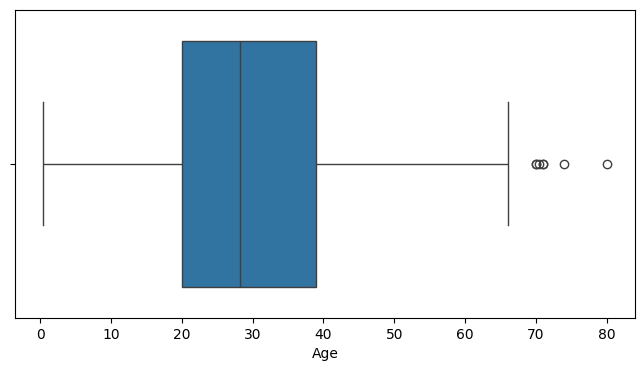

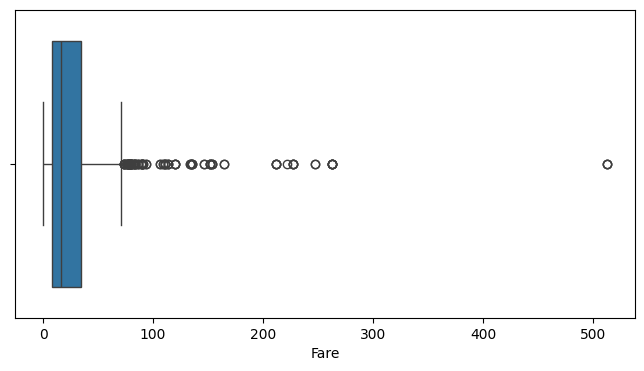

In [8]:
plt.figure(figsize = (8, 4))
sns.boxplot(x=titanic_data['Age'])
plt.show()

plt.figure(figsize = (8, 4))
sns.boxplot(x=titanic_data['Fare'])
plt.show()

**Handle Missing Values**

**1. Moderate / Class-wise Mean Imputation (Recommended)**

Impute Age by Pclass mean to respect subgroup differences.

Impute Embarked by most frequent value (mode).

Convert Cabin to binary HasCabin (1 if cabin present, 0 if missing).

In [9]:
titanic_data2 = titanic_data.copy()
titanic_data2.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,106
SibSp,0
Parch,0
Fare,0
Cabin,581
Embarked,2


In [10]:
# Fill Age using mean per Pclass
titanic_data2['Age'] = titanic_data2.groupby('Pclass')['Age']\
                                  .transform(lambda x: x.fillna(x.mean()))

In [11]:
# Fill Embarked using mode (most frequent)
titanic_data2['Embarked'].fillna(titanic_data2['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_7042/2940459670.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data2['Embarked'].fillna(titanic_data2['Embarked'].mode()[0], inplace=True)


In [12]:
# Create HasCabin feature and drop original Cabin column
titanic_data2['HasCabin'] = titanic_data2['Cabin'].notna().astype(int)
titanic_data2.drop(columns=['Cabin'], inplace=True)

In [13]:
# Verify missing values are handled
print("Missing values after imputation:\n")
titanic_data2.isna().sum()

Missing values after imputation:



,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
HasCabin,0


**2. Optional: KNN Imputer for Age (Alternative Method)**

KNN imputation uses neighboring passengers to fill missing numeric values.

In [14]:
titanic_data3 = titanic_data.copy()
titanic_data3.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,106
SibSp,0
Parch,0
Fare,0
Cabin,581
Embarked,2


In [15]:
imputer = KNNImputer(n_neighbors=5)
titanic_data3['Age'] = imputer.fit_transform(titanic_data3[['Age']])

# Verify missing values are handled
print("Missing values after KNN imputation for 'Age' column:\n")
titanic_data3.isna().sum()

Missing values after KNN imputation for 'Age' column:



,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,581
Embarked,2


**Outlier Detection and Removal**

Identify and remove rows that are outliers in both Age and Fare.

Avoid removing too many rows to preserve data.

In [16]:
# Detect outliers in Age and Fare using IQR
Q1 = titanic_data[['Age', 'Fare']].quantile(0.25)
Q3 = titanic_data[['Age', 'Fare']].quantile(0.75)
IQR = Q3 - Q1

# Outlier mask per value
outliers_mask = (
    (titanic_data[['Age','Fare']] < (Q1 - 1.5 * IQR)) |
    (titanic_data[['Age','Fare']] > (Q3 + 1.5 * IQR))
)

# AND: outlier in both Age and Fare
outliers_all = outliers_mask.all(axis=1)

# OR: outlier in either Age or Fare
outliers_any = outliers_mask.any(axis=1)

print("Outliers in BOTH Age and Fare (AND):", outliers_all.sum())
print("Outliers in EITHER Age or Fare (OR):", outliers_any.sum())

print("Shape before:", titanic_data.shape)
print("Shape after AND removal:", titanic_data[~outliers_all].shape)
print("Shape after OR removal:", titanic_data[~outliers_any].shape)


Outliers in BOTH Age and Fare (AND): 0
Outliers in EITHER Age or Fare (OR): 109
Shape before: (784, 9)
Shape after AND removal: (784, 9)
Shape after OR removal: (675, 9)


**Feature Scaling**

Scale numeric features to [0,1] range using Min–Max scaling.

Helps distance-based models like KNN and SVM.

In [17]:
titanic_data_clean = titanic_data[~outliers_any]

In [18]:
titanic_data_clean.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C


In [19]:
scaler = MinMaxScaler()
titanic_data_clean.loc[:, ['Age', 'Fare']] = scaler.fit_transform(titanic_data_clean[['Age', 'Fare']])

In [20]:
titanic_data_clean.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,0.329064,1,0,0.101707,NaN,S
1,1,1,female,0.573041,1,0,1.000000,C85,C


**Encode Categorical Features**

Convert Sex to numeric (0 = male, 1 = female).

OneHotEncoder Embarked to avoid ordinal bias.

HasCabin is already numeric, no encoding needed.

In [21]:
titanic_data_clean = titanic_data.copy()
titanic_data_clean.Sex.unique()

array(['male', 'female'], dtype=object)

In [22]:
# Label encoder Sex safely
le = LabelEncoder()
titanic_data_clean.loc[:, 'Sex'] = le.fit_transform(titanic_data_clean['Sex'])

print("Sex Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# One-hot encoder Embarked
titanic_data_clean = pd.get_dummies(
    titanic_data_clean,
    columns=['Embarked'],
    drop_first=True
)

Sex Encoding: {'female': np.int64(0), 'male': np.int64(1)}


**Separate Features and Target**

Separate input features X and target variable Y.

In [23]:
X = titanic_data_clean.drop(columns=['Survived'])
Y = titanic_data_clean[['Survived']]

**Train–Test Split**

Split dataset into training (70%) and testing (30%).

Stratify by Survived to maintain class ratio.

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.7, stratify=Y, random_state=3
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (548, 9)
Testing Features Shape: (236, 9)


In [25]:
print("Train target distribution:\n\n", Y_train.value_counts(normalize=True))
print("\n\nTest target distribution:\n\n", Y_test.value_counts(normalize=True))

Train target distribution:

 Survived
0           0.587591
1           0.412409
Name: proportion, dtype: float64


Test target distribution:

 Survived
0           0.588983
1           0.411017
Name: proportion, dtype: float64


**Optional Visualizations**

Visualize cleaned, scaled numeric features.

Confirm preprocessing steps.


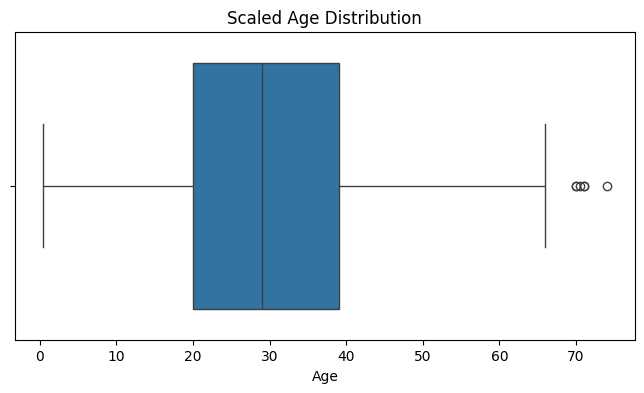

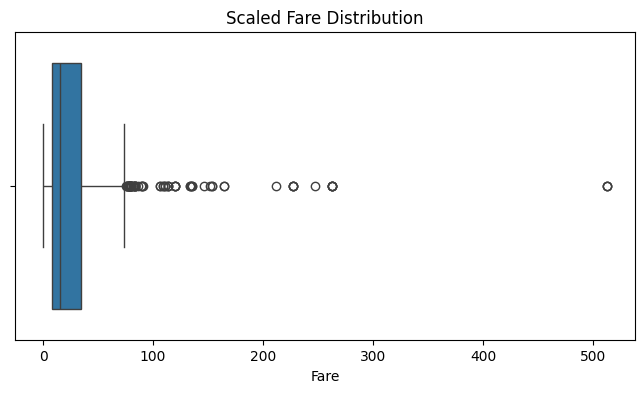

In [26]:
# Age distribution after imputation and scaling
plt.figure(figsize = (8, 4))
sns.boxplot(x=X_train['Age'])
plt.title("Scaled Age Distribution")
plt.show()

# Fare distribution
plt.figure(figsize = (8, 4))
sns.boxplot(x=X_train['Fare'])
plt.title("Scaled Fare Distribution")
plt.show()

**Conclusion**

Titanic dataset was cleaned, missing values handled, outliers removed, and features were scaled and encoded. The data was then split into training and testing sets while preserving class distribution for model building.
